In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Exemplo

In [ ]:
rng = np.random.default_rng() # gerando amostra totalmente aleatória

In [3]:
score = np.clip(rng.normal(55,15,200), 0,100) # nossa variável explicativa, amostra normal e linear ((média, desvio padrão, quantidade da amostra), range)

In [4]:
print(score)

[43.99607517 63.75091824 56.52478657 64.24451889 28.62960218 68.6399762
 52.61053852 55.91894029 53.99080239 28.40378367 33.13594558 38.62612701
 38.94003031 34.07019359 46.79130176 70.7722159  33.74328615 31.50215715
 38.75219261 28.78963921 58.22197176 81.69062177 46.71946864 62.18755924
 67.4391472  54.62278859 48.1540647  27.2006646  47.46825086 51.69205092
 45.57445342 38.74696264 77.56909882 28.50033983 72.99319535 34.37997241
 74.35047956 43.15633977 30.41512101 29.25964785 55.54005916 60.6053337
 79.42029251 39.49155643 52.09523741 84.30623353 74.17780955 42.41700259
 63.05922184 61.23083126 64.50600771 52.58055559 69.22629484 42.6365601
 45.53490233 48.04845217 48.84365695 43.83966894 58.13896271 37.4428064
 47.67015372 51.92920545 40.86200485 71.18164483 67.89088701 69.33727886
 46.97558929 42.17373783 56.59934831 84.88918095 75.68143424 61.88572506
 57.24308376 50.52374494 39.39070391 75.87731639 28.58368675 41.77358254
 45.30469746 59.15010358 31.42994743 62.11842599 57.488

In [5]:
p_true = 1 / (1 + np.exp(-(-8 + 0.12 * score))) # função logística, tranformar os valores em probabilidade

In [6]:
print(p_true)

[0.06177616 0.41340914 0.22846031 0.42784285 0.01030826 0.55892421
 0.15620565 0.21589899 0.17929905 0.01003544 0.01757258 0.03341176
 0.03464989 0.01961642 0.08432032 0.62073425 0.01887604 0.01448942
 0.03390378 0.01050604 0.26632215 0.8584985  0.08365714 0.36877099
 0.52315784 0.1907313  0.09783525 0.00869805 0.09080792 0.14222227
 0.07370886 0.03388323 0.78722718 0.01015121 0.68117642 0.02034424
 0.71546116 0.05618718 0.01274002 0.01110885 0.2083017  0.32577433
 0.82206997 0.03693315 0.14822746 0.89252037 0.71122421 0.05166341
 0.39343563 0.34247137 0.43554094 0.15573201 0.57619077 0.05296961
 0.07338547 0.09672233 0.10538613 0.06069723 0.26438034 0.02911758
 0.09282818 0.14572955 0.0432494  0.63223043 0.5366607  0.57943963
 0.08604356 0.05025176 0.23004127 0.89904895 0.74682919 0.36038051
 0.24400797 0.12596123 0.03650509 0.75124773 0.0102522  0.04800886
 0.07152899 0.28864222 0.0143662  0.36684197 0.24948103 0.0139005
 0.28920076 0.94324031 0.69821352 0.01610794 0.25650191 0.07495

In [ ]:
# Gerando 200 observações para os 200 valores acima, se o valor é sim ou não, vai gerar números binários
y = (rng.random(200) < p_true).astype(int)

In [8]:
print(y)

[1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1
 0 0 0 0 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 0 0
 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 1 1 0
 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 1 0 1 0 0 0 0 1 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0
 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0]


In [9]:
# Fazendo o ajuste
X = score [:,None]
clt = LogisticRegression().fit(X,y)

In [10]:
print(clt.intercept_)
print(clt.coef_)

[-8.75664156]
[[0.13334771]]


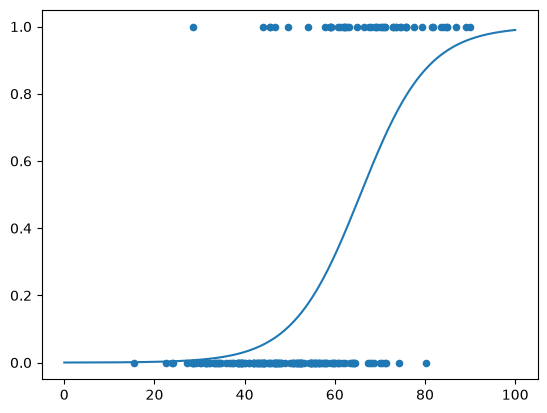

In [11]:
x_line = np.linspace(0, 100, 400)[:, None]
p_pred = clt.predict_proba(x_line)[:, 1]
plt.figure()
plt.scatter(score, y, s=20)
plt.plot(x_line.ravel(), p_pred)
plt.show()